# 3 - Utilizando CNN para classificação de objetos em imagens
Equipe:
*   Andre Lopes
*   Elias
*   Igor

**Link do github**: https://github.com/torres-elias/deep-learning-ufpb

**Tech Report**:
  [Learning Multiple Layers of Features from Tiny Images](https://www.cs.toronto.edu/~kriz/learning-features-2009-TR.pdf), Alex Krizhevsky, 2009.



# Importação e visualização da base de dados



In [ ]:
#Importação de bibliotecas comumente usadas durante o código
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
#Baixando a base de dados
!wget https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz

#extraindo a base de dados
!tar -xvzf cifar-10-python.tar.gz

--2026-03-08 01:24:51--  https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz
Resolving www.cs.toronto.edu (www.cs.toronto.edu)... 128.100.3.30
Connecting to www.cs.toronto.edu (www.cs.toronto.edu)|128.100.3.30|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 170498071 (163M) [application/x-gzip]
Saving to: ‘cifar-10-python.tar.gz’

cifar-10-python.tar 100%[===================>] 162.60M  7.75MB/s    in 61s     

2026-03-08 01:25:52 (2.66 MB/s) - ‘cifar-10-python.tar.gz’ saved [170498071/170498071]

cifar-10-batches-py/
cifar-10-batches-py/data_batch_4
cifar-10-batches-py/readme.html
cifar-10-batches-py/test_batch
cifar-10-batches-py/data_batch_3
cifar-10-batches-py/batches.meta
cifar-10-batches-py/data_batch_2
cifar-10-batches-py/data_batch_5
cifar-10-batches-py/data_batch_1


## Convertendo base de dados em dicionário


In [ ]:
import pickle

def unpickle(file):
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
    return dict

In [ ]:
# Carregando todas as batches de treino
X_train = []
y_train = []

for i in range(1,6):
    batch = unpickle(f"cifar-10-batches-py/data_batch_{i}")
    X_train.append(batch[b'data'])
    y_train.extend(batch[b'labels'])

X_train = np.vstack(X_train)
y_train = np.array(y_train)

print(X_train.shape)

(50000, 3072)


In [ ]:
# Carregando o treino
test_batch = unpickle("cifar-10-batches-py/test_batch")

X_test = test_batch[b'data']
y_test = np.array(test_batch[b'labels'])

print(X_test.shape)

(10000, 3072)


In [ ]:
# Carregando nome das classes
meta = unpickle("cifar-10-batches-py/batches.meta")

# Label foi salvo como bytes, então transformo em string
label_names = meta[b'label_names']
label_names = [label.decode("utf-8") for label in meta[b'label_names']]

print(label_names)

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## Testando imagens (Opcional)

In [ ]:
batch1 = unpickle("cifar-10-batches-py/data_batch_1")

print(batch1.keys())

dict_keys([b'batch_label', b'labels', b'data', b'filenames'])


In [ ]:
# Acessando imagens e os labels
# x é a imagem em sí, enquanto que y é o label da imagem
# que vai de 1 a 9, dizendo qual objeto ela representa

import numpy as np

X = batch1[b'data']
y = batch1[b'labels']

print(X.shape)
print("Label:", y[0])

(10000, 3072)
Label: 6


(32, 32, 3)


(np.float64(-0.5), np.float64(31.5), np.float64(31.5), np.float64(-0.5))

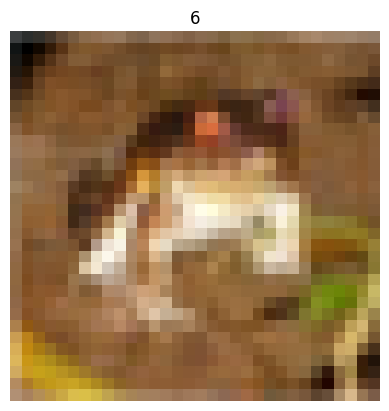

In [ ]:
# Convertendo vetor em imagem.
imagem = X[0]

imagem = imagem.reshape(3,32,32).transpose(1,2,0)

print(imagem.shape)

# Mostrando a imagem
plt.imshow(imagem)
plt.title(y[0])
plt.axis("off")

# Pré-processamento de dados

In [ ]:
#Verificando se existem duplicatas exatas nos dados
unique_images = np.unique(X_train, axis=0)

duplicates = X_train.shape[0] - unique_images.shape[0]
print("Duplicatas:", duplicates)

Duplicatas: 0


In [ ]:
#Verificando se existem valores nulos
print(np.isnan(X_train).any())
print(np.any(X_train == None))
print(np.isnan(y_train).any())
np.sum(np.any(np.isnan(X_train), axis=1))

False
False
False


np.int64(0)

In [ ]:
#Transformando vetor em imagem
X_train = X_train.reshape(-1,3,32,32).transpose(0,2,3,1)
X_test = X_test.reshape(-1,3,32,32).transpose(0,2,3,1)

In [ ]:
#Normalização por min-maxing scaling
X_train = (X_train.astype(np.float32)) / np.float32(255.0)
X_test = (X_test.astype(np.float32)) / np.float32(255.0)

## Data Augumentation

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Criar um gerador de dados com augmentations
datagen = ImageDataGenerator(
    rotation_range=15,       # rotaciona as imagens até 15 graus
    width_shift_range=0.1,   # deslocamento horizontal
    height_shift_range=0.1,  # deslocamento vertical
    horizontal_flip=True,    # flip horizontal aleatório
    zoom_range=0.1           # zoom aleatório
)

In [ ]:
from sklearn.model_selection import train_test_split

# Separar conjunto de validação
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train, y_train, test_size=0.1, random_state=42
)

datagen.fit(X_train)

In [ ]:
X_train

array([[[[0.23137255, 0.24313726, 0.24705882],
         [0.16862746, 0.18039216, 0.1764706 ],
         [0.19607843, 0.1882353 , 0.16862746],
         ...,
         [0.61960787, 0.5176471 , 0.42352942],
         [0.59607846, 0.49019608, 0.4       ],
         [0.5803922 , 0.4862745 , 0.40392157]],

        [[0.0627451 , 0.07843138, 0.07843138],
         [0.        , 0.        , 0.        ],
         [0.07058824, 0.03137255, 0.        ],
         ...,
         [0.48235294, 0.34509805, 0.21568628],
         [0.46666667, 0.3254902 , 0.19607843],
         [0.47843137, 0.34117648, 0.22352941]],

        [[0.09803922, 0.09411765, 0.08235294],
         [0.0627451 , 0.02745098, 0.        ],
         [0.19215687, 0.10588235, 0.03137255],
         ...,
         [0.4627451 , 0.32941177, 0.19607843],
         [0.47058824, 0.32941177, 0.19607843],
         [0.42745098, 0.28627452, 0.16470589]],

        ...,

        [[0.8156863 , 0.6666667 , 0.3764706 ],
         [0.7882353 , 0.6       , 0.13333334]

# Aplicando o CNN

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.layers import Dropout

# Criar a CNN
model = Sequential([
    Conv2D(64, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),

    Conv2D(128,(3,3),activation='relu',padding='same'),
    Conv2D(128,(3,3),activation='relu',padding='same'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')  # 10 classes
])

#  Compilar o modelo com sparse_categorical_crossentropy
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Resumo do modelo
model.summary()

# Treinar o modelo
history = model.fit(
    datagen.flow(X_train_sub, y_train_sub, batch_size=64),
    steps_per_epoch=len(X_train)//64,
    epochs=50,
    validation_data=(X_val, y_val)
)


#  Avaliar no conjunto de teste
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,388,234 (5.30 MB)

 Trainable params: 1,388,234 (5.30 MB)

...

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


703/781 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - accuracy: 0.2775 - loss: 1.9183

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


781/781 ━━━━━━━━━━━━━━━━━━━━ 46s 53ms/step - accuracy: 0.2862 - loss: 1.8979 - val_accuracy: 0.5068 - val_loss: 1.3542
Epoch 2/50
781/781 ━━━━━━━━━━━━━━━━━━━━ 71s 43ms/step - accuracy: 0.4965 - loss: 1.3682 - val_accuracy: 0.5858 - val_loss: 1.1288
Epoch 3/50
781/781 ━━━━━━━━━━━━━━━━━━━━ 33s 42ms/step - accuracy: 0.5961 - loss: 1.1288 - val_accuracy: 0.6840 - val_loss: 0.8899
Epoch 4/50
781/781 ━━━━━━━━━━━━━━━━━━━━ 33s 43ms/step - accuracy: 0.6469 - loss: 1.0005 - val_accuracy: 0.7220 - val_loss: 0.7894
Epoch 5/50
781/781 ━━━━━━━━━━━━━━━━━━━━ 41s 43ms/step - accuracy: 0.6818 - loss: 0.9091 - val_accuracy: 0.7454 - val_loss: 0.7297
Epoch 6/50
781/781 ━━━━━━━━━━━━━━━━━━━━ 33s 42ms/step - accuracy: 0.7080 - loss: 0.8384 - val_accuracy: 0.7326 - val_loss: 0.7875
Epoch 7/50
781/781 ━━━━━━━━━━━━━━━━━━━━ 33s 43ms/step - accuracy: 0.7185 - loss: 0.8085 - val_accuracy: 0.7516 - val_loss: 0.7366
Epoch 8/50
781/781 ━━━━━━━━━━━━━━━━━━━━ 33s 42ms/step - accuracy: 0.7365 - loss: 0.7623 - val_accurac

#Resultados

##Curva de Erro

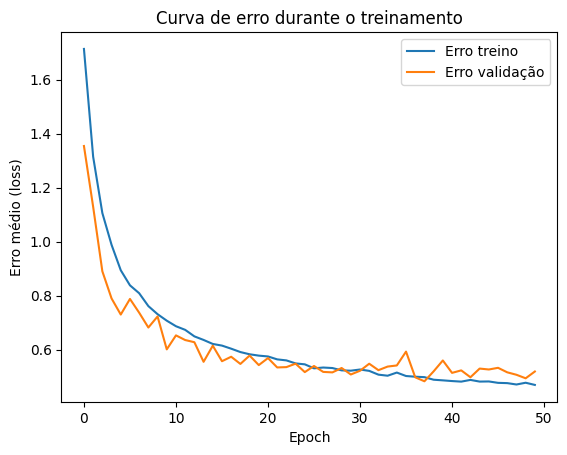

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history['loss'], label='Erro treino')
plt.plot(history.history['val_loss'], label='Erro validação')
plt.xlabel('Epoch')
plt.ylabel('Erro médio (loss)')
plt.title('Curva de erro durante o treinamento')
plt.legend()
plt.show()

##Matriz Confusão

In [ ]:
import numpy as np

y_pred = model.predict(X_test)

# classe prevista
y_pred_classes = np.argmax(y_pred, axis=1)

# classe real (já é inteiro)
y_true = y_test

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


In [ ]:
from sklearn.metrics import confusion_matrix

matrix_confusão = confusion_matrix(y_true, y_pred_classes)
print(matrix_confusão)

[[891  18  18   4   4   2   1   3  30  29]
 [  5 946   0   0   0   1   0   1   8  39]
 [ 65   7 725  16  44  45  60  23   5  10]
 [ 36  20  40 598  38 110  83  23  22  30]
 [ 22   6  30  18 789  12  50  61   7   5]
 [ 14   4  21  92  21 774  22  35   6  11]
 [ 10   9  14  14  12   4 924   2   6   5]
 [ 19   4   9   5  18  22  11 892   4  16]
 [ 63  17   2   3   2   0   1   1 889  22]
 [ 15  62   1   3   0   1   0   0   8 910]]


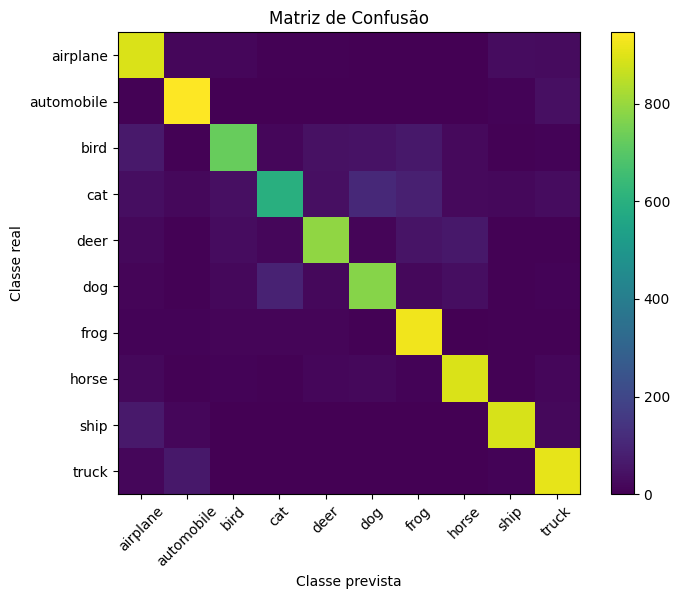

In [ ]:
classes = [
'airplane','automobile','bird','cat','deer',
'dog','frog','horse','ship','truck'
]

plt.figure(figsize=(8,6))
plt.imshow(matrix_confusão)
plt.xticks(range(10), classes, rotation=45)
plt.yticks(range(10), classes)
plt.xlabel("Classe prevista")
plt.ylabel("Classe real")
plt.title("Matriz de Confusão")
plt.colorbar()
plt.show()